In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.constants import (
    ORIGINAL_DATA_PATH,
    PREPROCESSING_CATEGORICAL_COLS,
    COLOUR_PALETTE,
)
from src.preprocessing import (
    load_original_dataset,
    filter_to_health_sector,
    filter_to_timeframe,
    set_categorical_dtypes,
)
from src.visualisations import (
    plot_vertical_bar_chart,
    plot_pie_chart,
    plot_horizontal_stacked_crosstab,
    plot_vertical_stacked_crosstab,
)

In [2]:
df_original = load_original_dataset(ORIGINAL_DATA_PATH)
df_original.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206140 entries, 0 to 206139
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   BI Reference                206140 non-null  object
 1   Year                        206140 non-null  int64 
 2   Quarter                     206140 non-null  object
 3   Data Subject Type           206140 non-null  object
 4   Data Type                   206140 non-null  object
 5   Decision Taken              206140 non-null  object
 6   Incident Category           206140 non-null  object
 7   Incident Type               206140 non-null  object
 8   No. Data Subjects Affected  206140 non-null  object
 9   Sector                      206140 non-null  object
 10  Time Taken to Report        206140 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.3+ MB


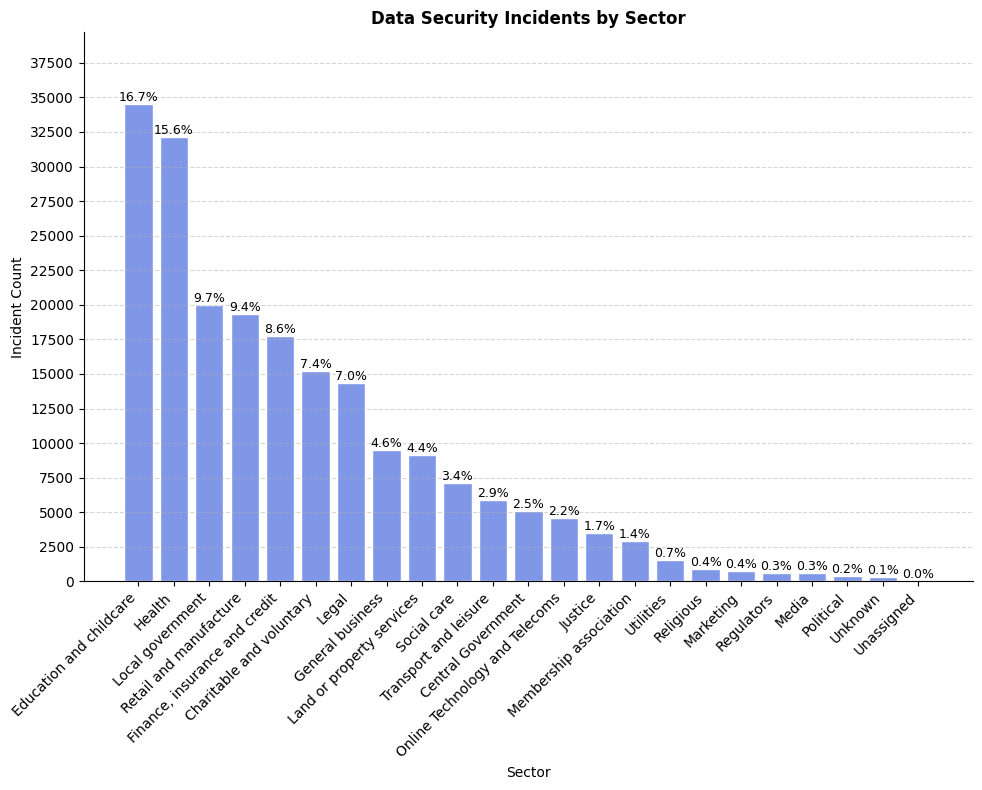


Total sectors: 23
                                count  percentage
Sector                                           
Education and childcare         34525   16.748326
Health                          32127   15.585039
Local government                19991    9.697778
Retail and manufacture          19308    9.366450
Finance, insurance and credit   17744    8.607742
Charitable and voluntary        15229    7.387698
Legal                           14329    6.951101
General business                 9520    4.618221
Land or property services        9148    4.437761
Social care                      7103    3.445717
Transport and leisure            5908    2.866013
Central Government               5054    2.451732
Online Technology and Telecoms   4614    2.238285
Justice                          3503    1.699331
Membership association           2937    1.424760
Utilities                        1536    0.745125
Religious                         894    0.433686
Marketing                      

In [3]:
sector_counts = df_original["Sector"].value_counts()
sector_summary = plot_vertical_bar_chart(
    sector_counts,
    title="Data Security Incidents by Sector",
    xlabel="Sector",
    ylabel="Incident Count",
    sort_by="none",
    figsize=(10, 8),
    annotate="percentage",
    colour="#8097e8",
    step=2500,
)
print(f"\nTotal sectors: {df_original['Sector'].nunique()}")
print(sector_summary)

In [4]:
df_health_original = filter_to_health_sector(df_original)
df_health_original = filter_to_timeframe(df_health_original, 2021, 2, 2025, 4)
df_health_original = set_categorical_dtypes(df_health_original)
df_health_original.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22879 entries, 65264 to 206136
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   bi_reference               22879 non-null  category
 1   year                       22879 non-null  category
 2   quarter                    22879 non-null  category
 3   data_subject_type          22879 non-null  category
 4   data_type                  22879 non-null  category
 5   decision_taken             22879 non-null  category
 6   incident_category          22879 non-null  category
 7   incident_type              22879 non-null  category
 8   no_data_subjects_affected  22879 non-null  category
 9   time_taken_to_report       22879 non-null  category
dtypes: category(10)
memory usage: 764.5 KB


In [5]:
total_rows = len(df_health_original)
unique_bi_refs = df_health_original["bi_reference"].nunique()
duplicate_ratio = (total_rows - unique_bi_refs) / total_rows * 100

print(f"Total rows in the dataset: {total_rows:,}")
print(f"Unique BI References: {unique_bi_refs:,}")
print(f"Rows representing duplicate characteristics: {total_rows - unique_bi_refs:,}")
print(f"Duplication rate: {duplicate_ratio:.2f}%")

Total rows in the dataset: 22,879
Unique BI References: 10,098
Rows representing duplicate characteristics: 12,781
Duplication rate: 55.86%


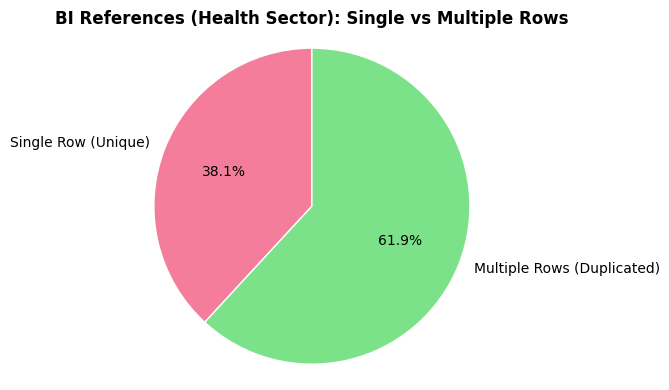

                            count  percentage
Single Row (Unique)          3851        38.1
Multiple Rows (Duplicated)   6247        61.9


In [6]:
bi_ref_counts = df_health_original["bi_reference"].value_counts()
bi_ref_series = pd.Series({
    "Single Row (Unique)":       (bi_ref_counts == 1).sum(),
    "Multiple Rows (Duplicated)": (bi_ref_counts > 1).sum(),
})

bi_ref_summary = plot_pie_chart(
    bi_ref_series,
    title="BI References (Health Sector): Single vs Multiple Rows",
    total=bi_ref_series.sum(),
)
print(bi_ref_summary)

In [7]:
duplicated_bi_refs = df_health_original[df_health_original["bi_reference"].duplicated(keep=False)]
total_groups = duplicated_bi_refs["bi_reference"].nunique()

# nunique per group per column
varying_columns = duplicated_bi_refs.groupby("bi_reference", observed=False).nunique()

# A column varies in a group if nunique > 1
varying_counts = (varying_columns > 1).sum()

varying_counts = (
    varying_counts
    .sort_values(ascending=False)
    .rename("count")
    .to_frame()
)
varying_counts["percentage"] = (varying_counts["count"] / total_groups * 100)

print(f"Columns that vary across duplicate rows:\n {varying_counts}")
print("\nBreach characteristics per incident:")
print(df_health_original.groupby("bi_reference", observed=False).size().describe())

Columns that vary across duplicate rows:
                            count  percentage
data_type                   5675   90.843605
data_subject_type           1689   27.036978
year                           0    0.000000
quarter                        0    0.000000
decision_taken                 0    0.000000
incident_category              0    0.000000
incident_type                  0    0.000000
no_data_subjects_affected      0    0.000000
time_taken_to_report           0    0.000000

Breach characteristics per incident:
count    10098.000000
mean         2.265696
std          2.808294
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         66.000000
dtype: float64


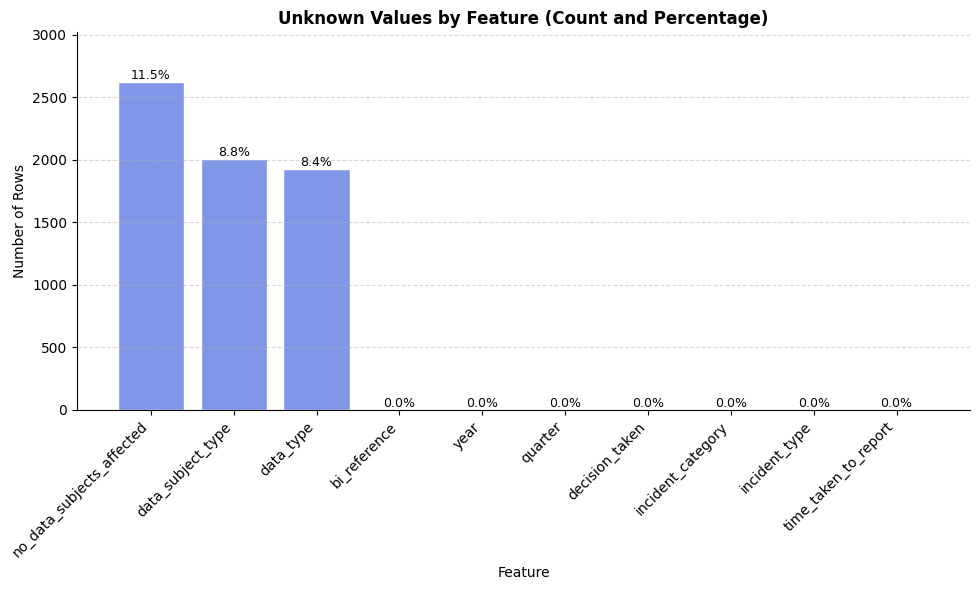

                           count  percentage
no_data_subjects_affected   2625   11.473404
data_subject_type           2009    8.780978
data_type                   1929    8.431313
bi_reference                   0    0.000000
year                           0    0.000000
quarter                        0    0.000000
decision_taken                 0    0.000000
incident_category              0    0.000000
incident_type                  0    0.000000
time_taken_to_report           0    0.000000


In [8]:
unknown_counts = (
    df_health_original[PREPROCESSING_CATEGORICAL_COLS]
    .isin(["Unknown"]).sum()
    .sort_values(ascending=False)
)
unknown_summary = plot_vertical_bar_chart(
    unknown_counts,
    title="Unknown Values by Feature (Count and Percentage)",
    xlabel="Feature",
    ylabel="Number of Rows",
    sort_by="none",
    total=len(df_health_original),
    annotate="percentage",
    colour="#8097e8",
    step=500,
)
print(unknown_summary)

In [9]:
df_health_unique = df_health_original.drop_duplicates(subset=["bi_reference"], keep="first").reset_index(drop=True)
print(f"Unique rows in health sector df: {len(df_health_unique)}")

Unique rows in health sector df: 10098


In [10]:
# Aggregate total rows per year-quarter (duplicated BI references)
total_incidents = (
    df_health_original
    .groupby(["year", "quarter"], observed=True)
    .size()
    .reset_index(name="total_incidents")
)

# Aggregate unique incidents per year-quarter
unique_incidents = (
    df_health_unique
    .groupby(["year", "quarter"], observed=True)
    .size()
    .reset_index(name="unique_incidents")
)

quarter_to_num = {"Qtr 1": 1, "Qtr 2": 2, "Qtr 3": 3, "Qtr 4": 4}

incidents_over_time = total_incidents.merge(unique_incidents, on=["year", "quarter"])
incidents_over_time["quarter_num"] = incidents_over_time["quarter"].astype(str).map(quarter_to_num)
incidents_over_time["year_num"] = incidents_over_time["year"].astype(str).astype(int)
incidents_over_time = incidents_over_time.sort_values(by=["year_num", "quarter_num"]).reset_index(drop=True)
incidents_over_time["period"] = (incidents_over_time["year"].astype(str) + " " + incidents_over_time["quarter"].astype(str))

# Display table with both totals and a duplicate count
display_df = incidents_over_time[["year", "quarter", "total_incidents", "unique_incidents"]].copy()
display_df["duplicates"] = display_df["total_incidents"] - display_df["unique_incidents"]
display_df.columns = ["Year", "Quarter", "Total Rows", "Unique Incidents", "Duplicates"]

print("Healthcare data security incidents over time:")
print(display_df.to_string(index=False))

print(f"\nOverall Summary:")
print(f"\tTotal rows across all periods: {display_df['Total Rows'].sum():,}")
print(f"\tTotal unique incidents: {display_df['Unique Incidents'].sum():,}")
print(f"\tTotal duplicate incidents: {display_df['Duplicates'].sum():,}")

Healthcare data security incidents over time:
Year Quarter  Total Rows  Unique Incidents  Duplicates
2021   Qtr 2        1286               603         683
2021   Qtr 3         915               432         483
2021   Qtr 4         991               461         530
2022   Qtr 1         913               421         492
2022   Qtr 2         937               431         506
2022   Qtr 3        1548               481        1067
2022   Qtr 4         938               440         498
2023   Qtr 1        1077               454         623
2023   Qtr 2        1019               458         561
2023   Qtr 3        1038               501         537
2023   Qtr 4        1191               503         688
2024   Qtr 1        1245               572         673
2024   Qtr 2        1497               616         881
2024   Qtr 3        1620               677         943
2024   Qtr 4        1154               577         577
2025   Qtr 1        1231               582         649
2025   Qtr 2       

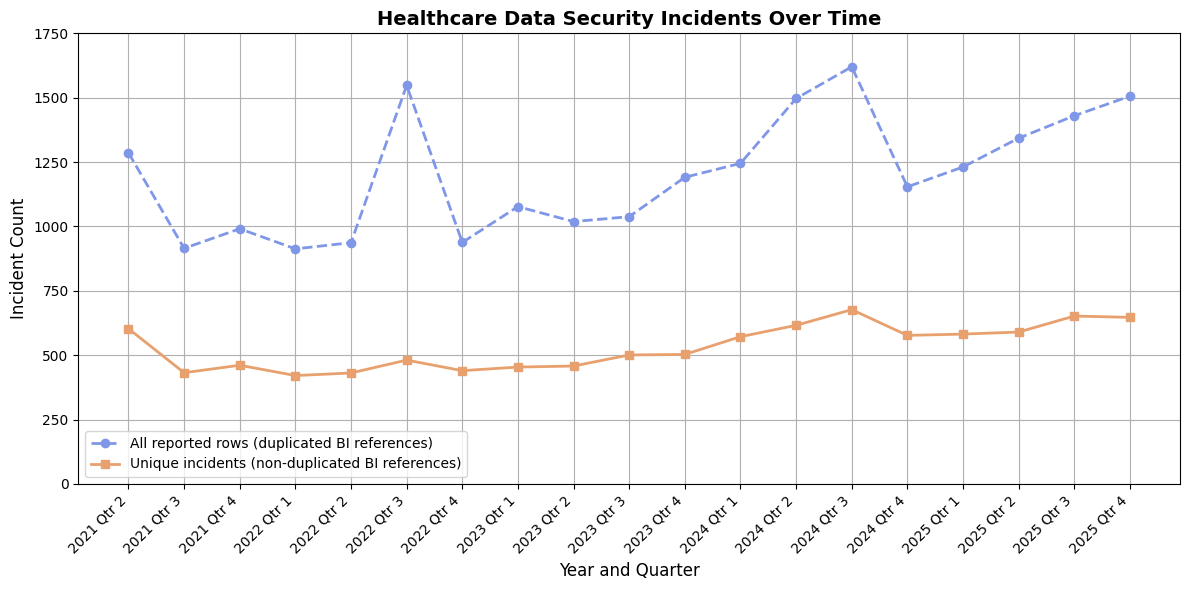

In [11]:
# Line chart of incidents over time
plt.figure(figsize=(12, 6))
plt.plot(
    incidents_over_time.index,
    incidents_over_time["total_incidents"],
    marker="o", label="All reported rows (duplicated BI references)",
    linestyle="--", linewidth=2, markersize=6, color="#8097e8",
)
plt.plot(
    incidents_over_time.index,
    incidents_over_time["unique_incidents"],
    marker="s", label="Unique incidents (non-duplicated BI references)",
    linewidth=2, markersize=6, color="#e8a16e",
)
plt.xticks(
    ticks=incidents_over_time.index,
    labels=incidents_over_time["period"],
    rotation=45, ha="right",
)
plt.yticks(np.arange(0, incidents_over_time["total_incidents"].max() * 1.2, 250))
plt.title("Healthcare Data Security Incidents Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year and Quarter", fontsize=12)
plt.ylabel("Incident Count", fontsize=12)
plt.legend(loc="best", frameon=True)
plt.grid(True, linestyle="-")
plt.tight_layout()
plt.show()

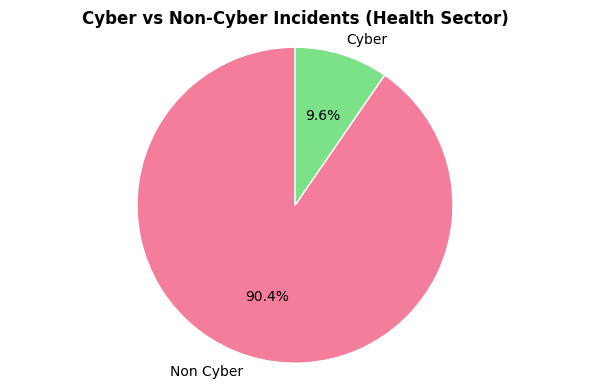

                   count  percentage
incident_category                   
Non Cyber           9129        90.4
Cyber                969         9.6


In [12]:
# Cyber vs Non-Cyber incidents
incident_category_counts = df_health_unique["incident_category"].value_counts()
incident_category_summary = plot_pie_chart(
    incident_category_counts,
    title="Cyber vs Non-Cyber Incidents (Health Sector)",
    total=len(df_health_unique),
    colours=COLOUR_PALETTE[:2],
)
print(incident_category_summary)

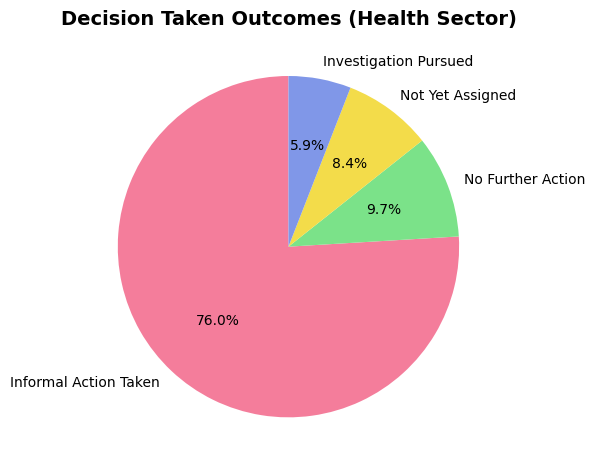

Decision taken counts:
	Informal Action Taken: 7,670
	No Further Action: 982
	Not Yet Assigned: 848
	Investigation Pursued: 598


In [13]:
# Decision taken outcomes (including "Not Yet Assigned" since this is pre-aggregation)
decision_counts = df_health_unique["decision_taken"].value_counts()
decision_percents = (decision_counts / len(df_health_unique)) * 100

plt.title("Decision Taken Outcomes (Health Sector)", fontsize=14, fontweight="bold")
plt.pie(
    decision_counts.values,
    labels=decision_counts.index,
    autopct="%1.1f%%",
    colors=COLOUR_PALETTE[:len(decision_counts)],
    startangle=90,
    textprops={"fontsize": 10},
)
plt.tight_layout()
plt.show()
print("Decision taken counts:")
for decision, count in decision_counts.items():
    print(f"\t{decision}: {count:,}")

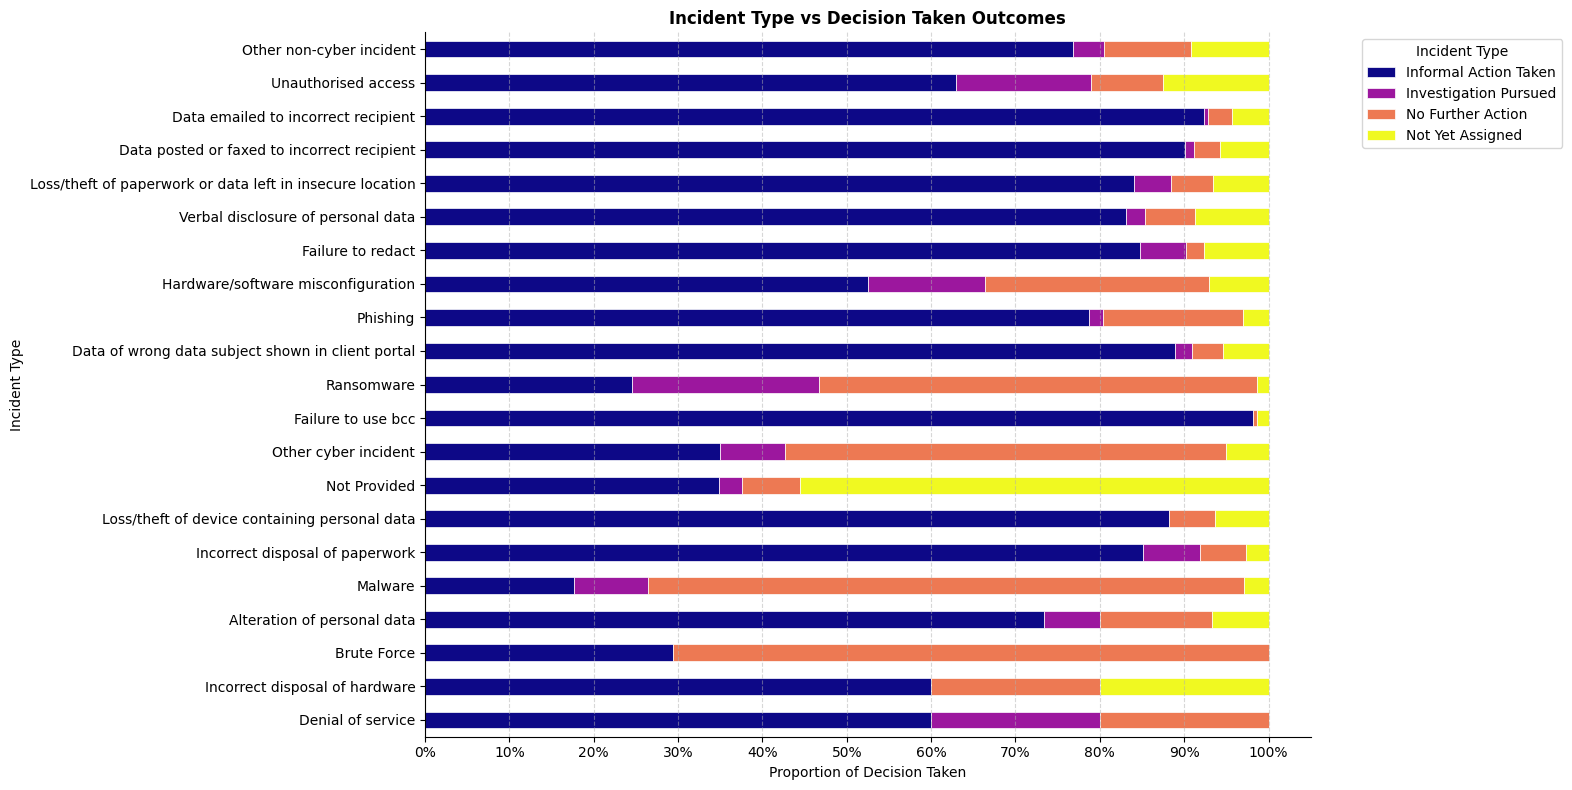

decision_taken                                      Informal Action Taken  \
incident_type                                                               
Denial of service                                                   0.600   
Incorrect disposal of hardware                                      0.600   
Brute Force                                                         0.294   
Alteration of personal data                                         0.733   
Malware                                                             0.176   
Incorrect disposal of paperwork                                     0.851   
Loss/theft of device containing personal data                       0.882   
Not Provided                                                        0.349   
Other cyber incident                                                0.350   
Failure to use bcc                                                  0.982   
Ransomware                                                          0.246   

In [14]:
# Incident type vs decision taken
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["incident_type"],
    df_health_unique["decision_taken"],
    title="Incident Type vs Decision Taken Outcomes",
    xlabel="Decision Taken",
    ylabel="Incident Type",
)
print(proportions)

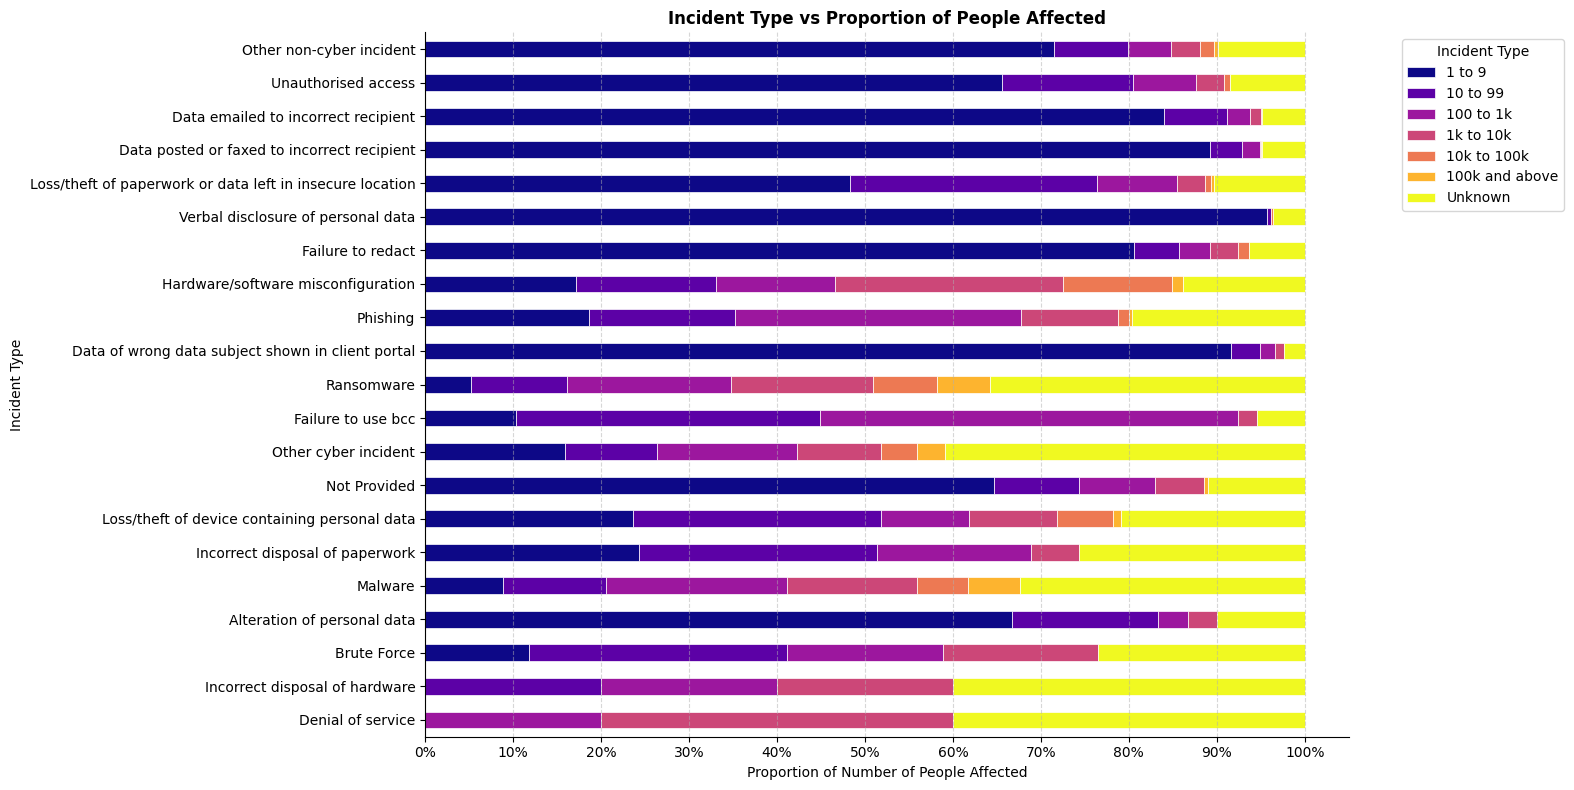

no_data_subjects_affected                           1 to 9  10 to 99  \
incident_type                                                          
Denial of service                                    0.000     0.000   
Incorrect disposal of hardware                       0.000     0.200   
Brute Force                                          0.118     0.294   
Alteration of personal data                          0.667     0.167   
Malware                                              0.088     0.118   
Incorrect disposal of paperwork                      0.243     0.270   
Loss/theft of device containing personal data        0.236     0.282   
Not Provided                                         0.647     0.096   
Other cyber incident                                 0.159     0.105   
Failure to use bcc                                   0.103     0.345   
Ransomware                                           0.053     0.109   
Data of wrong data subject shown in client portal    0.916     0

In [15]:
# Incident type vs number of people affected
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["incident_type"],
    df_health_unique["no_data_subjects_affected"],
    title="Incident Type vs Proportion of People Affected",
    xlabel="Number of People Affected",
    ylabel="Incident Type",
)
print(proportions)

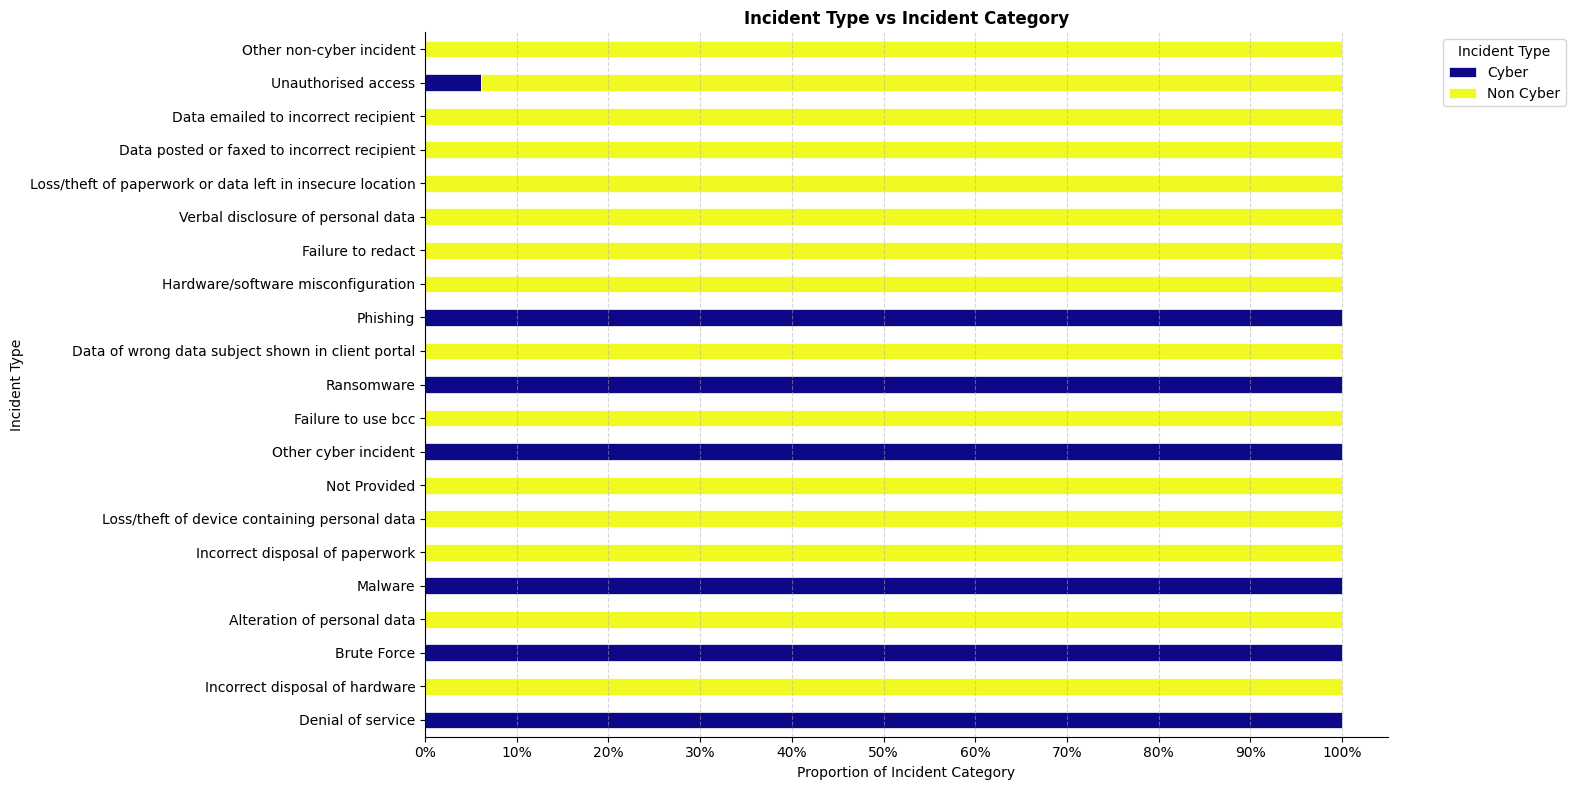

incident_category                                   Cyber  Non Cyber
incident_type                                                       
Denial of service                                   1.000      0.000
Incorrect disposal of hardware                      0.000      1.000
Brute Force                                         1.000      0.000
Alteration of personal data                         0.000      1.000
Malware                                             1.000      0.000
Incorrect disposal of paperwork                     0.000      1.000
Loss/theft of device containing personal data       0.000      1.000
Not Provided                                        0.000      1.000
Other cyber incident                                1.000      0.000
Failure to use bcc                                  0.000      1.000
Ransomware                                          1.000      0.000
Data of wrong data subject shown in client portal   0.000      1.000
Phishing                          

In [16]:
# Incident type vs incident category
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["incident_type"],
    df_health_unique["incident_category"],
    title="Incident Type vs Incident Category",
    xlabel="Incident Category",
    ylabel="Incident Type",
)
print(proportions)

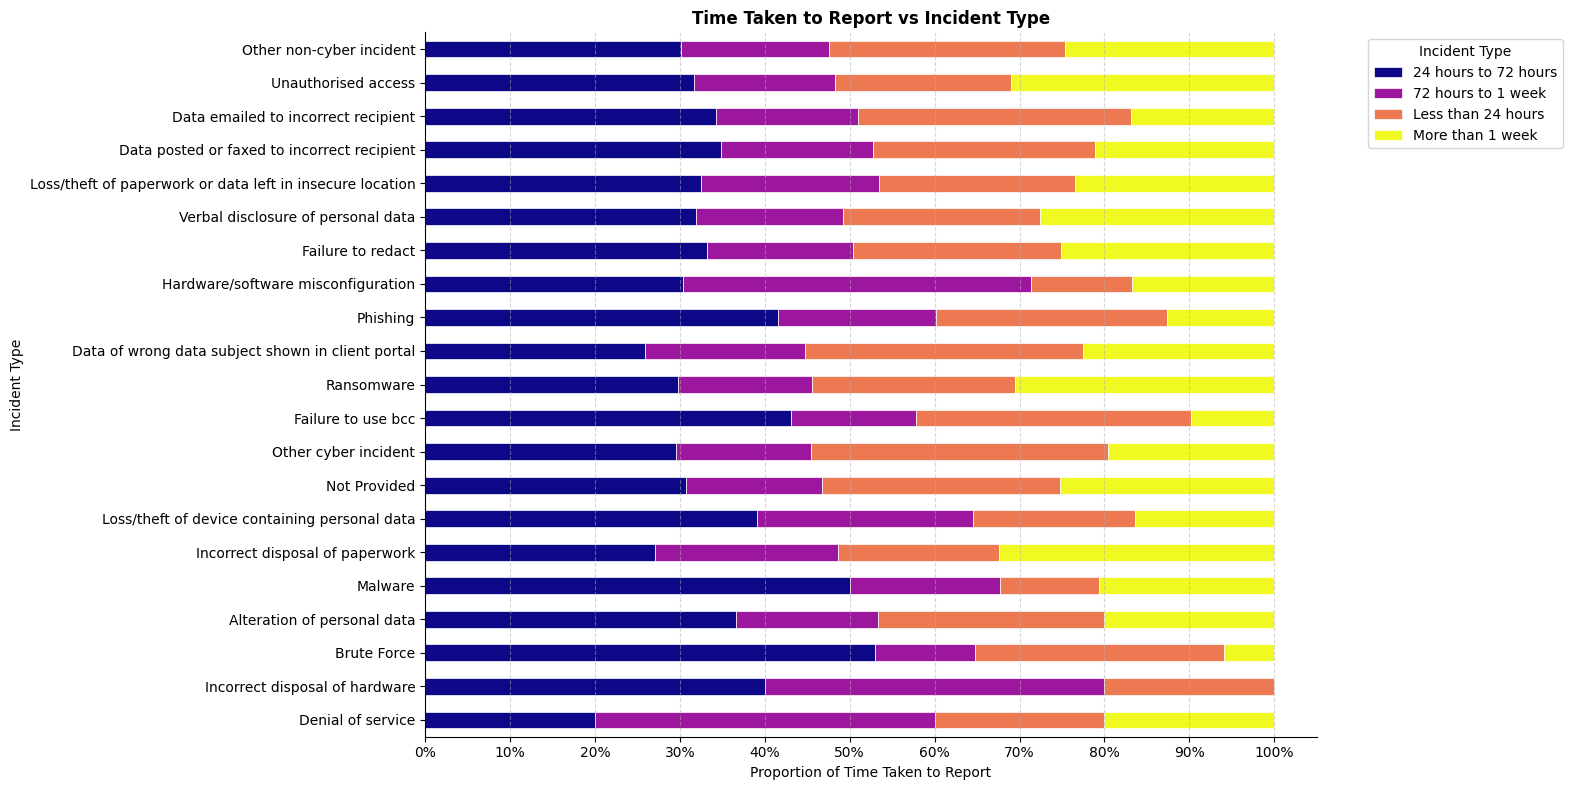

time_taken_to_report                                24 hours to 72 hours  \
incident_type                                                              
Denial of service                                                  0.200   
Incorrect disposal of hardware                                     0.400   
Brute Force                                                        0.529   
Alteration of personal data                                        0.367   
Malware                                                            0.500   
Incorrect disposal of paperwork                                    0.270   
Loss/theft of device containing personal data                      0.391   
Not Provided                                                       0.307   
Other cyber incident                                               0.295   
Failure to use bcc                                                 0.430   
Ransomware                                                         0.298   
Data of wron

In [17]:
# Time taken to report vs incident type
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["incident_type"],
    df_health_unique["time_taken_to_report"],
    title="Time Taken to Report vs Incident Type",
    xlabel="Time Taken to Report",
    ylabel="Incident Type",
)
print(proportions)

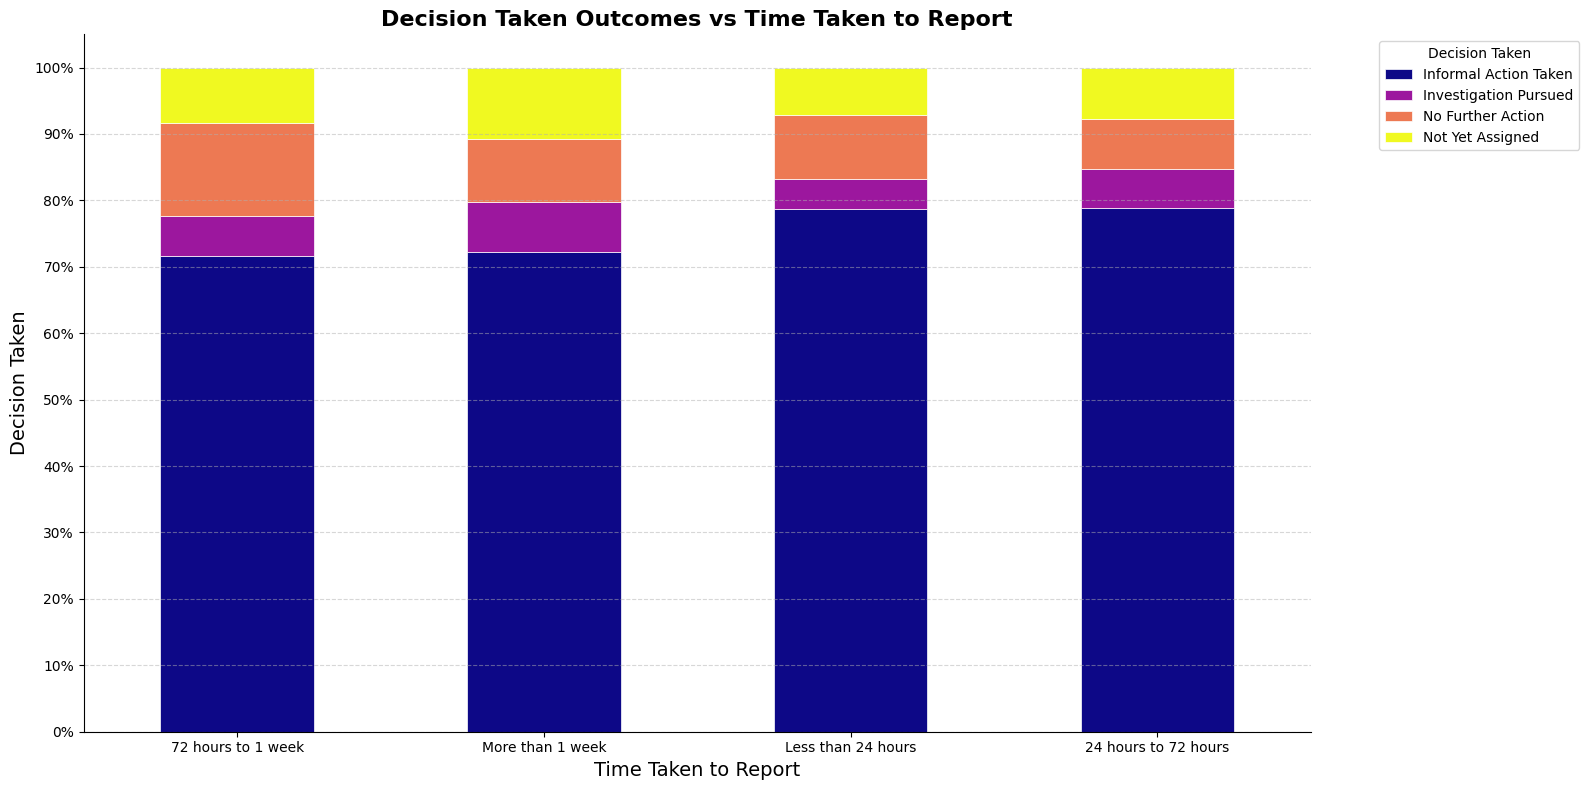

decision_taken        Informal Action Taken  Investigation Pursued  \
time_taken_to_report                                                 
72 hours to 1 week                    0.717                  0.059   
More than 1 week                      0.723                  0.076   
Less than 24 hours                    0.786                  0.045   
24 hours to 72 hours                  0.788                  0.059   

decision_taken        No Further Action  Not Yet Assigned  
time_taken_to_report                                       
72 hours to 1 week                0.141             0.083  
More than 1 week                  0.095             0.107  
Less than 24 hours                0.096             0.072  
24 hours to 72 hours              0.075             0.078  


In [18]:
# Decision taken vs time taken to report
proportions, counts = plot_vertical_stacked_crosstab(
    df_health_unique["time_taken_to_report"],
    df_health_unique["decision_taken"],
    title="Decision Taken Outcomes vs Time Taken to Report",
    xlabel="Decision Taken",
    ylabel="Time Taken to Report",
)
print(proportions)

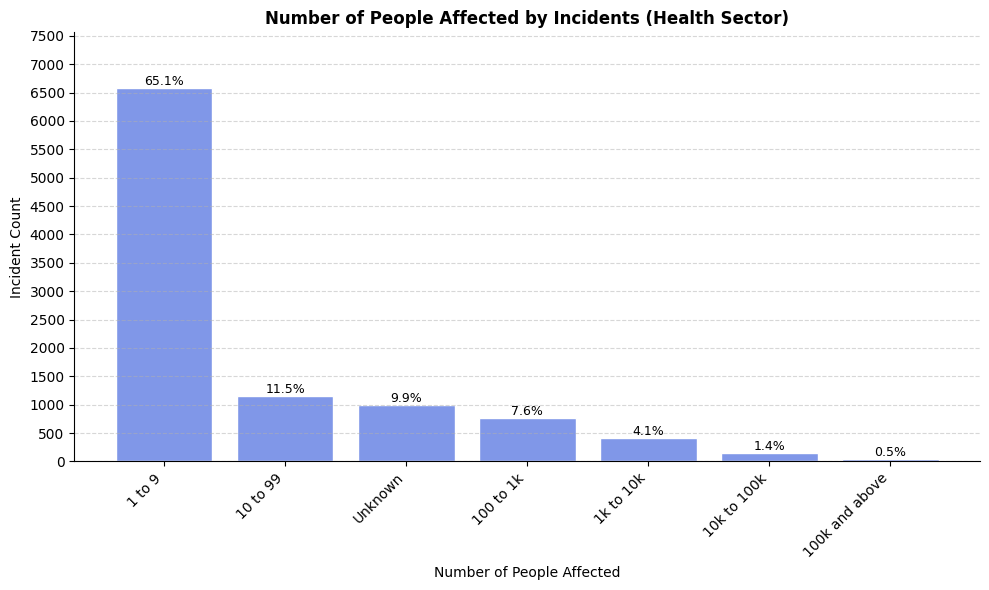

                           count  percentage
no_data_subjects_affected                   
1 to 9                      6574   65.102000
10 to 99                    1157   11.457714
Unknown                      996    9.863339
100 to 1k                    770    7.625272
1k to 10k                    412    4.080016
10k to 100k                  143    1.416122
100k and above                46    0.455536


In [19]:
# Number of people affected (Health sector)
people_summary = plot_vertical_bar_chart(
    df_health_unique["no_data_subjects_affected"].value_counts(),
    title="Number of People Affected by Incidents (Health Sector)",
    xlabel="Number of People Affected",
    ylabel="Incident Count",
    sort_by="none",
    annotate="percent",
    colour="#8097e8",
    step=500,
)
print(people_summary)

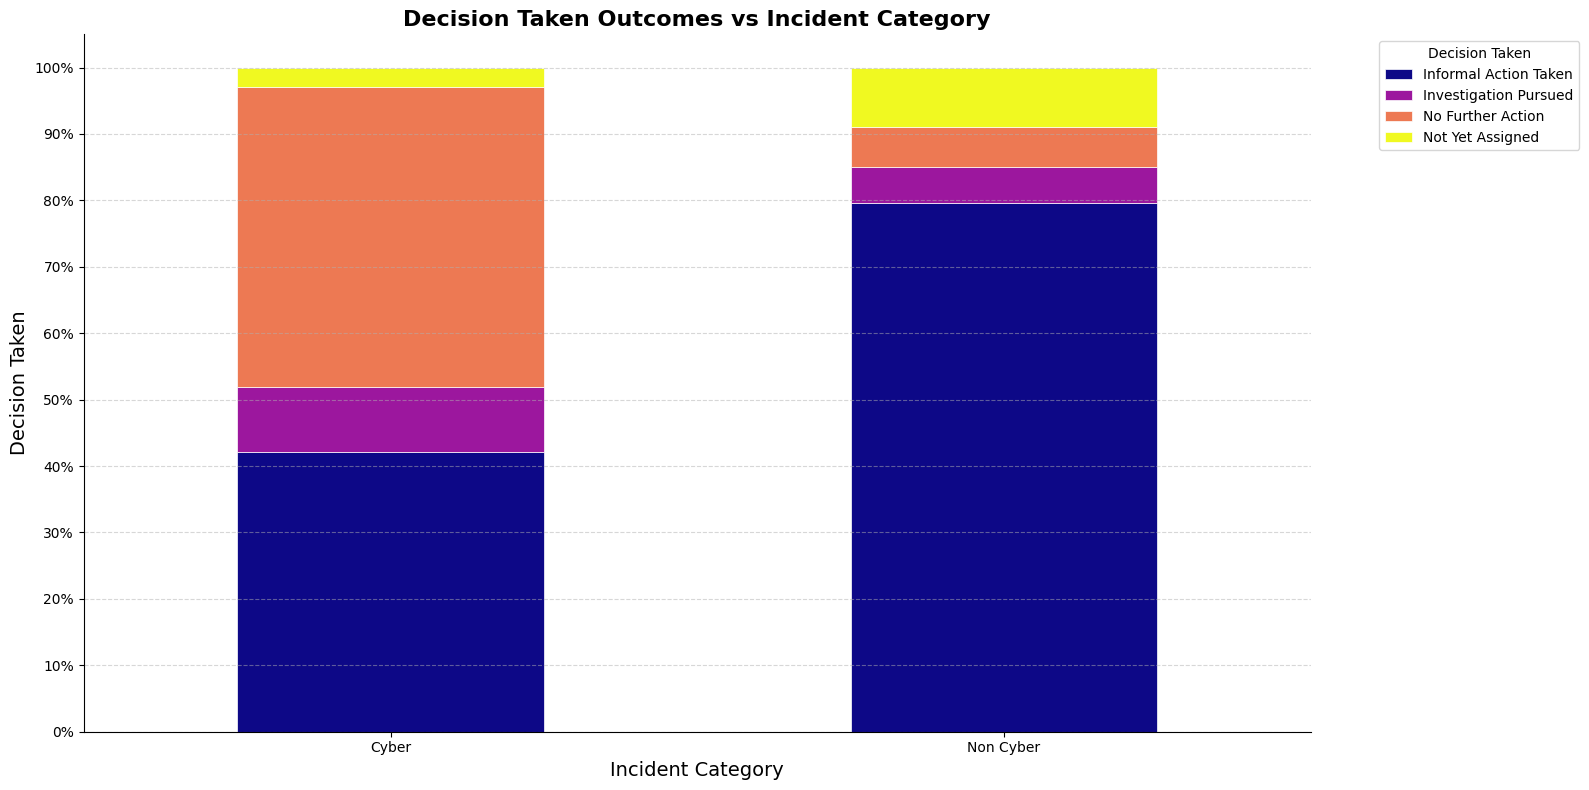

decision_taken     Informal Action Taken  Investigation Pursued  \
incident_category                                                 
Cyber                              0.421                  0.098   
Non Cyber                          0.795                  0.055   

decision_taken     No Further Action  Not Yet Assigned  
incident_category                                       
Cyber                          0.452             0.029  
Non Cyber                      0.060             0.090  


In [20]:
# Decision taken vs incident category
proportions, counts = plot_vertical_stacked_crosstab(
    df_health_unique["incident_category"],
    df_health_unique["decision_taken"],
    title="Decision Taken Outcomes vs Incident Category",
    xlabel="Decision Taken",
    ylabel="Incident Category",
)
print(proportions)

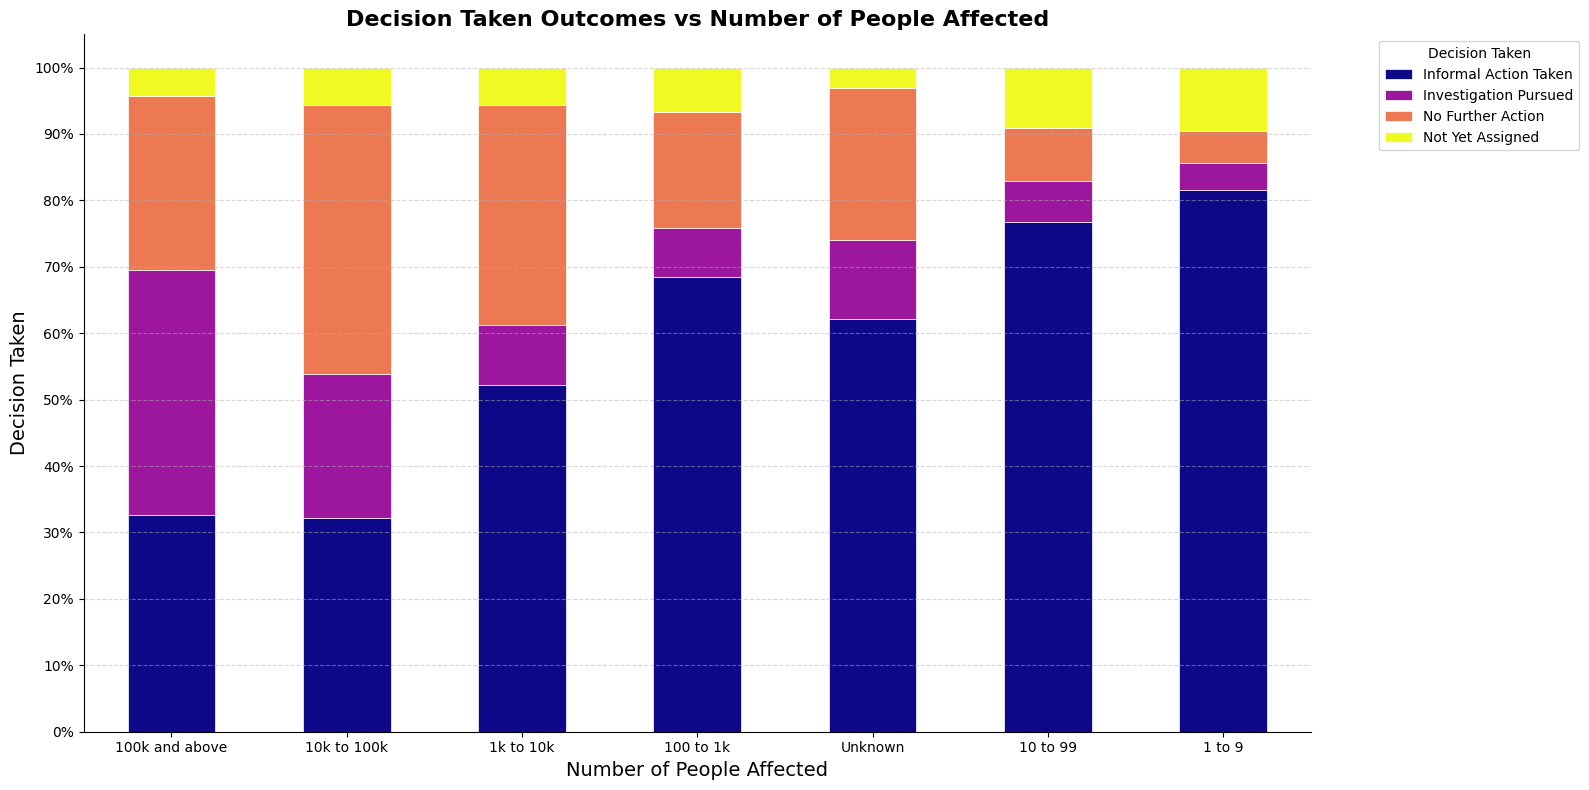

decision_taken             Informal Action Taken  Investigation Pursued  \
no_data_subjects_affected                                                 
100k and above                             0.326                  0.370   
10k to 100k                                0.322                  0.217   
1k to 10k                                  0.522                  0.090   
100 to 1k                                  0.684                  0.074   
Unknown                                    0.621                  0.119   
10 to 99                                   0.768                  0.062   
1 to 9                                     0.815                  0.040   

decision_taken             No Further Action  Not Yet Assigned  
no_data_subjects_affected                                       
100k and above                         0.261             0.043  
10k to 100k                            0.406             0.056  
1k to 10k                              0.333             0.056  

In [21]:
# Decision taken vs No. of people affected
proportions, counts = plot_vertical_stacked_crosstab(
    df_health_unique["no_data_subjects_affected"],
    df_health_unique["decision_taken"],
    title="Decision Taken Outcomes vs Number of People Affected",
    xlabel="Decision Taken",
    ylabel="Number of People Affected",
)
print(proportions)

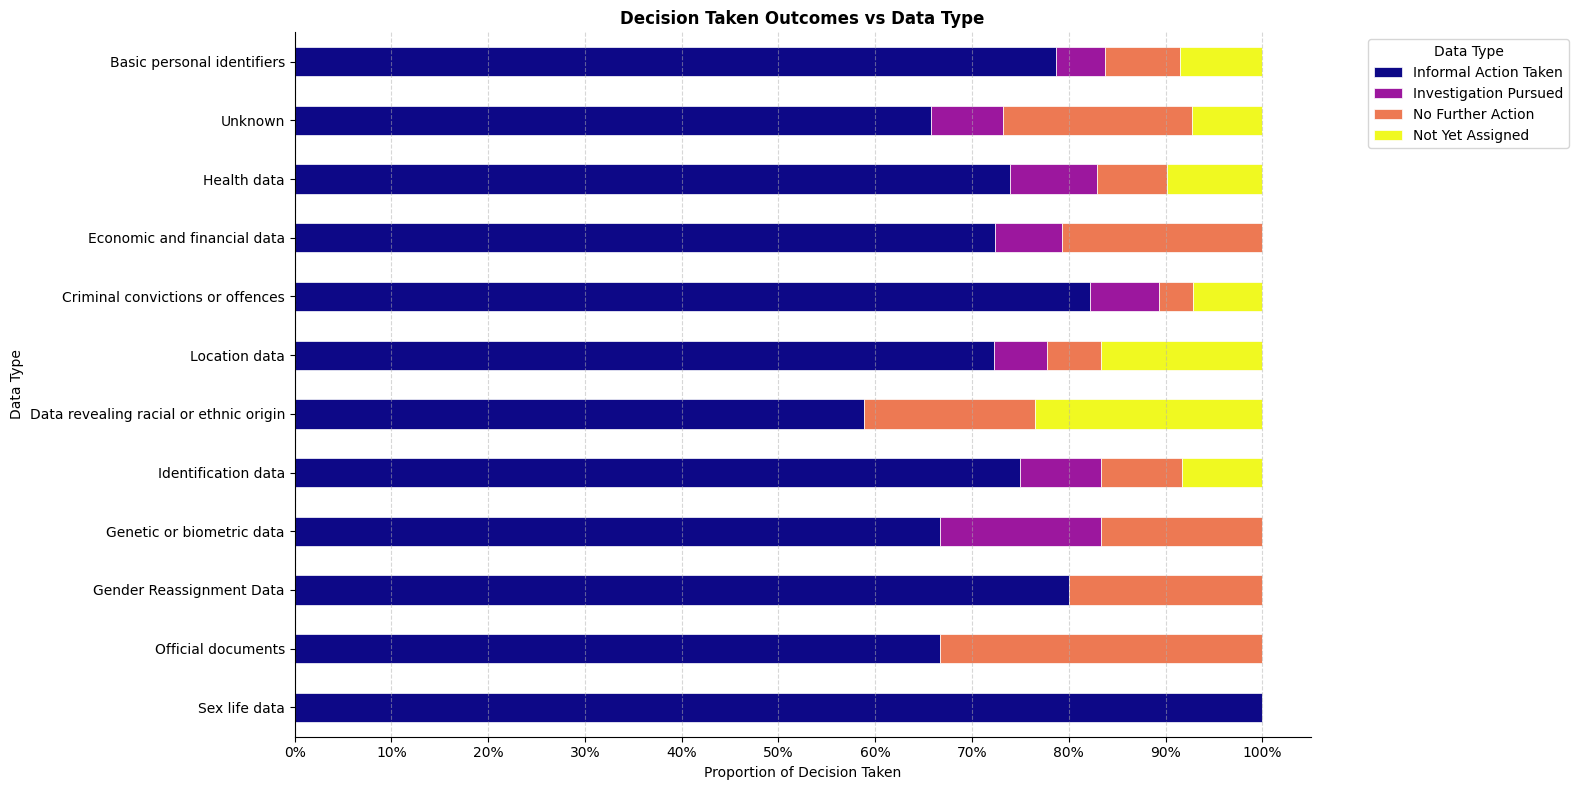

decision_taken                          Informal Action Taken  \
data_type                                                       
Sex life data                                           1.000   
Official documents                                      0.667   
Gender Reassignment Data                                0.800   
Genetic or biometric data                               0.667   
Identification data                                     0.750   
Data revealing racial or ethnic origin                  0.588   
Location data                                           0.722   
Criminal convictions or offences                        0.821   
Economic and financial data                             0.724   
Health data                                             0.739   
Unknown                                                 0.657   
Basic personal identifiers                              0.787   

decision_taken                          Investigation Pursued  \
data_type               

In [22]:
# Decision taken vs data type 
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["data_type"],
    df_health_unique["decision_taken"],
    title="Decision Taken Outcomes vs Data Type",
    xlabel="Decision Taken",
    ylabel="Data Type",
)
print(proportions)

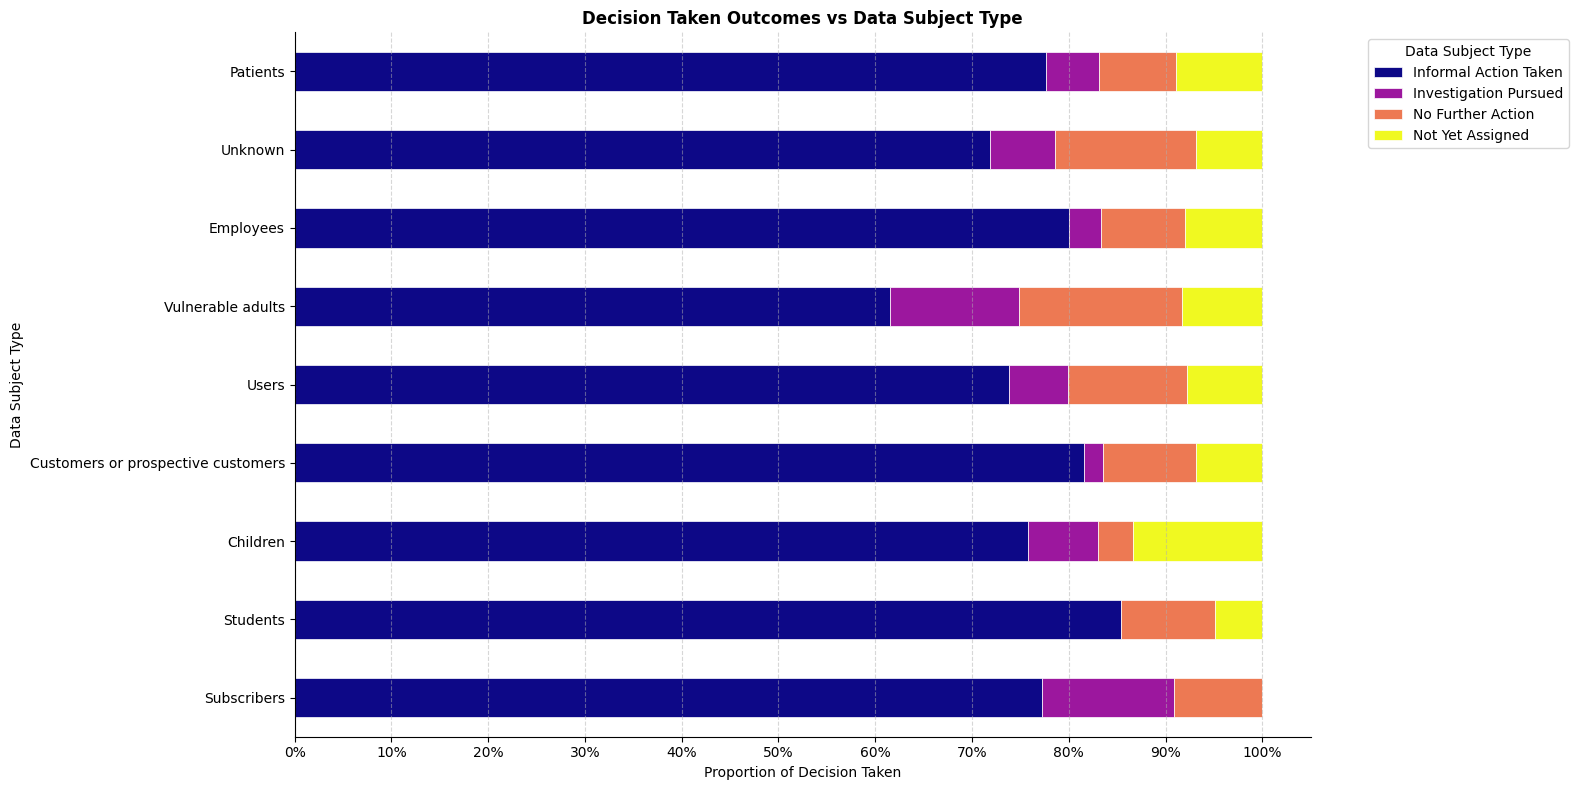

decision_taken                      Informal Action Taken  \
data_subject_type                                           
Subscribers                                         0.773   
Students                                            0.854   
Children                                            0.758   
Customers or prospective customers                  0.816   
Users                                               0.739   
Vulnerable adults                                   0.615   
Employees                                           0.801   
Unknown                                             0.718   
Patients                                            0.777   

decision_taken                      Investigation Pursued  No Further Action  \
data_subject_type                                                              
Subscribers                                         0.136              0.091   
Students                                            0.000              0.098   
Children

In [23]:
# Decision taken vs data subject type
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["data_subject_type"],
    df_health_unique["decision_taken"],
    title="Decision Taken Outcomes vs Data Subject Type",
    xlabel="Decision Taken",
    ylabel="Data Subject Type",
)
print(proportions)